# 04 — Evaluation
### Diabetic Retinopathy Detection | APTOS 2019

**Goal:** Thoroughly evaluate the best saved model.  
We will:
1. Load best checkpoint from training
2. Run full classification report
3. Plot confusion matrix
4. Analyse per-class performance
5. Visualize correct vs incorrect predictions
6. GradCAM — see what the model focuses on
7. Final summary

## 0. Imports & Setup

In [1]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import torch
import torch.nn as nn
from PIL import Image
from torchvision import transforms
from sklearn.metrics import (
    classification_report, confusion_matrix,
    cohen_kappa_score, accuracy_score
)

PROJECT_ROOT = os.getcwd()
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from utils.config       import Config
from utils.dataset      import set_seed, RetinopathyDataset, get_transforms
from utils.metrics      import evaluate, print_classification_report
from models.vgg16_model import VGG16Retinopathy

set_seed()
os.makedirs("outputs", exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device : {DEVICE}")

Device : cuda


---
## 1. Load Best Model & Val Set

In [2]:
# ── Load model ────────────────────────────────────────────────
model = VGG16Retinopathy(
    num_classes=Config.NUM_CLASSES,
    dropout=Config.DROPOUT
).to(DEVICE)

model.load_state_dict(
    torch.load(Config.SAVE_PATH, map_location=DEVICE)
)
model.eval()
print(f"Loaded checkpoint : {Config.SAVE_PATH}")

# ── Load val split ────────────────────────────────────────────
val_df = pd.read_csv("outputs/val_split.csv")
_, val_tf = get_transforms()
val_dataset = RetinopathyDataset(val_df, Config.TRAIN_IMGS, val_tf)

from torch.utils.data import DataLoader
val_loader = DataLoader(
    val_dataset,
    batch_size=Config.BATCH_SIZE,
    shuffle=False,
    num_workers=Config.NUM_WORKERS
)
print(f"Val samples : {len(val_dataset)}")

Loaded checkpoint : /teamspace/studios/this_studio/diabetic-retinopathy/outputs/best_model.pth
Val samples : 372


## 2. Classification Report

In [3]:
criterion = nn.CrossEntropyLoss()

val_loss, val_acc, val_kappa, all_preds, all_labels = evaluate(
    model, val_loader, criterion, DEVICE
)

print(f"Val Loss              : {val_loss:.4f}")
print(f"Val Accuracy          : {val_acc:.4f}  ({val_acc*100:.2f}%)")
print(f"Quadratic Kappa       : {val_kappa:.4f}")
print()
print("─" * 55)
print("Classification Report:")
print("─" * 55)
print_classification_report(all_labels, all_preds, Config.CLASS_NAMES)

Val Loss              : 0.9280
Val Accuracy          : 0.6720  (67.20%)
Quadratic Kappa       : 0.8022

───────────────────────────────────────────────────────
Classification Report:
───────────────────────────────────────────────────────
               precision    recall  f1-score   support

        No DR     0.9159    0.9800    0.9469       100
         Mild     0.7778    0.5676    0.6562        74
     Moderate     0.5918    0.5800    0.5859       100
       Severe     0.4043    0.4872    0.4419        39
Proliferative     0.5000    0.5593    0.5280        59

     accuracy                         0.6720       372
    macro avg     0.6380    0.6348    0.6318       372
 weighted avg     0.6817    0.6720    0.6726       372



## 3. Confusion Matrix

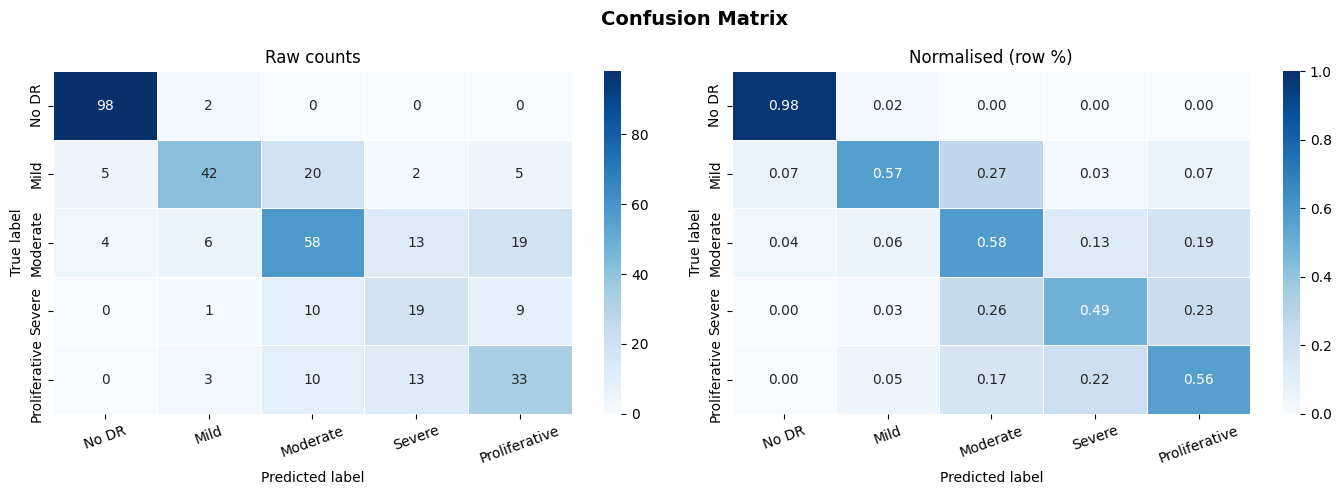

Saved: outputs/04_confusion_matrix.png


In [4]:
cm_raw = confusion_matrix(all_labels, all_preds)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Confusion Matrix", fontsize=14, fontweight="bold")

# ── Raw counts ────────────────────────────────────────────────
sns.heatmap(
    cm_raw, annot=True, fmt="d", cmap="Blues",
    xticklabels=Config.CLASS_NAMES,
    yticklabels=Config.CLASS_NAMES,
    ax=axes[0], linewidths=0.5
)
axes[0].set_title("Raw counts")
axes[0].set_ylabel("True label")
axes[0].set_xlabel("Predicted label")
axes[0].tick_params(axis="x", rotation=20)

# ── Normalised (row %) ────────────────────────────────────────
cm_norm = cm_raw.astype(float) / cm_raw.sum(axis=1, keepdims=True)
sns.heatmap(
    cm_norm, annot=True, fmt=".2f", cmap="Blues",
    xticklabels=Config.CLASS_NAMES,
    yticklabels=Config.CLASS_NAMES,
    ax=axes[1], linewidths=0.5, vmin=0, vmax=1
)
axes[1].set_title("Normalised (row %)")
axes[1].set_ylabel("True label")
axes[1].set_xlabel("Predicted label")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.savefig("outputs/04_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/04_confusion_matrix.png")

## 4. Per-Class Performance Bar Chart

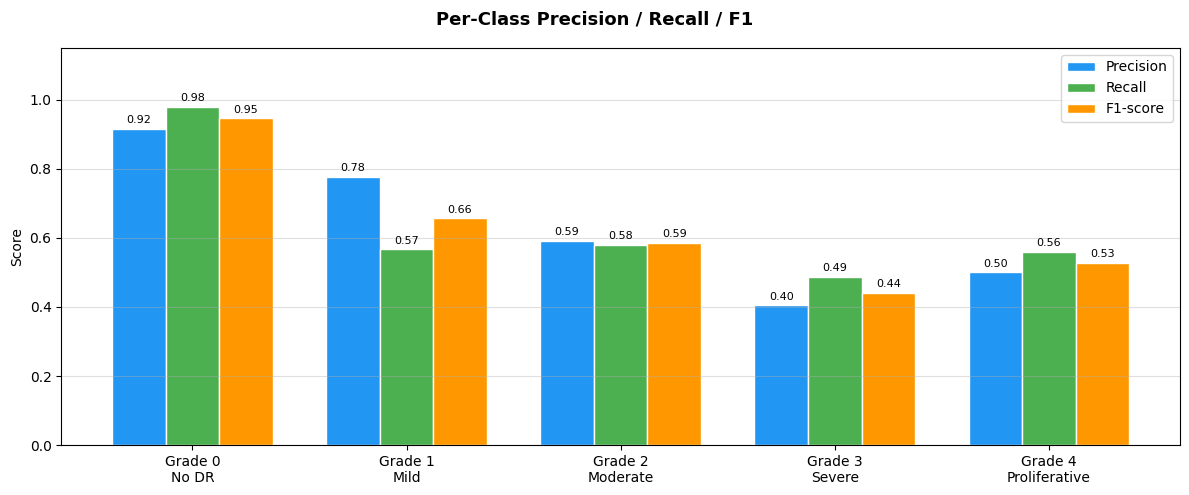

Saved: outputs/04_per_class_metrics.png


In [5]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(all_labels, all_preds, average=None, zero_division=0)
recall    = recall_score(all_labels, all_preds, average=None, zero_division=0)
f1        = f1_score(all_labels, all_preds, average=None, zero_division=0)

x     = np.arange(len(Config.CLASS_NAMES))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 5))
fig.suptitle("Per-Class Precision / Recall / F1",
             fontsize=13, fontweight="bold")

b1 = ax.bar(x - width, precision, width, label="Precision",
            color="#2196F3", edgecolor="white")
b2 = ax.bar(x,          recall,   width, label="Recall",
            color="#4CAF50", edgecolor="white")
b3 = ax.bar(x + width,  f1,       width, label="F1-score",
            color="#FF9800", edgecolor="white")

for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            h + 0.01, f"{h:.2f}",
            ha="center", va="bottom", fontsize=8
        )

ax.set_xticks(x)
ax.set_xticklabels(
    [f"Grade {i}\n{n}" for i, n in enumerate(Config.CLASS_NAMES)]
)
ax.set_ylim(0, 1.15)
ax.set_ylabel("Score")
ax.legend()
ax.grid(axis="y", alpha=0.4)

plt.tight_layout()
plt.savefig("outputs/04_per_class_metrics.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/04_per_class_metrics.png")

## 5. Correct vs Incorrect Predictions

Correct   : 250 / 372
Incorrect : 122 / 372


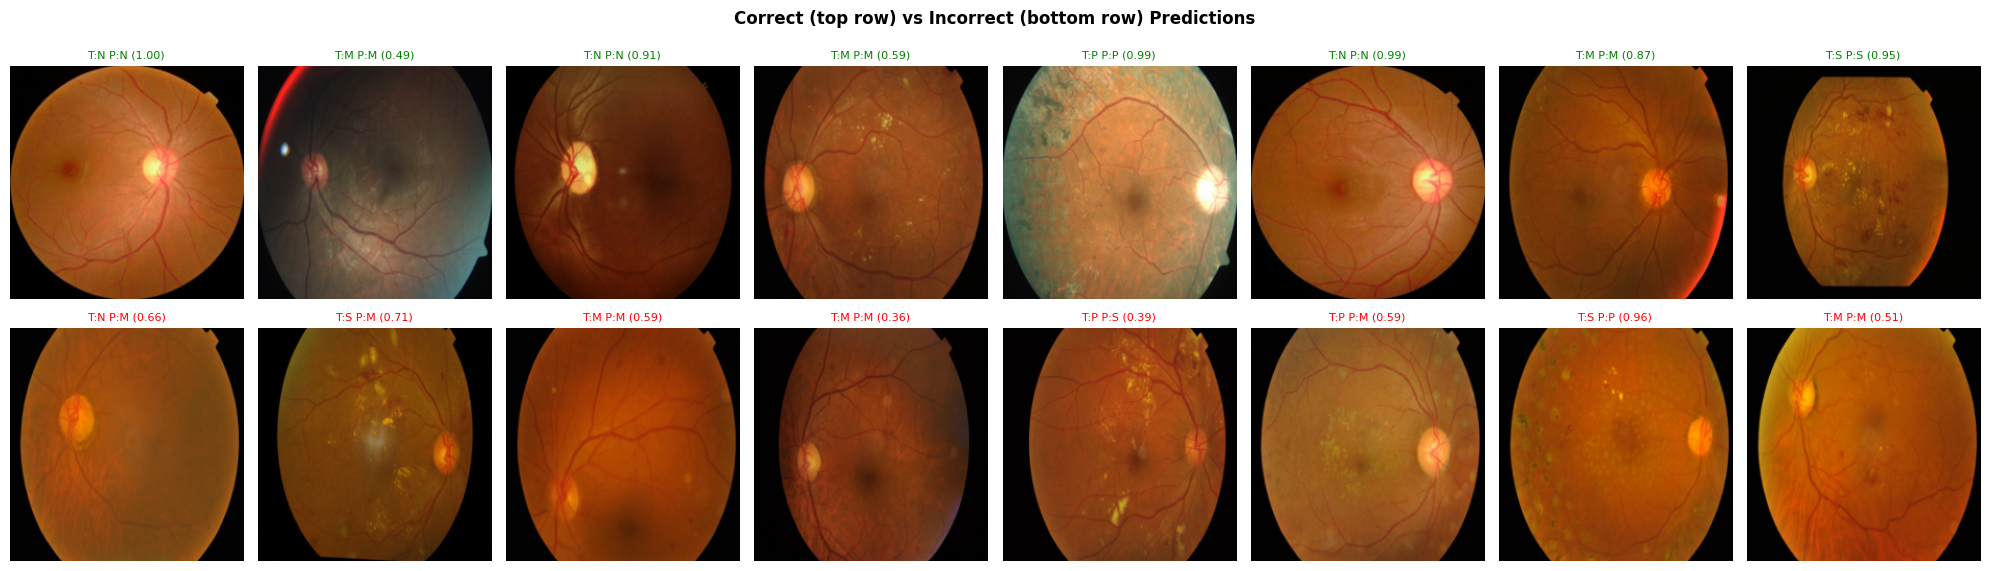

T = True label  |  P = Predicted  |  value = confidence


In [6]:
inv_normalize = transforms.Normalize(
    mean=[-m/s for m, s in zip(Config.MEAN, Config.STD)],
    std=[1/s for s in Config.STD]
)

correct_idx   = [i for i, (p, l) in enumerate(zip(all_preds, all_labels)) if p == l]
incorrect_idx = [i for i, (p, l) in enumerate(zip(all_preds, all_labels)) if p != l]

print(f"Correct   : {len(correct_idx)} / {len(all_labels)}")
print(f"Incorrect : {len(incorrect_idx)} / {len(all_labels)}")

import random
random.seed(Config.SEED)

n_show = min(8, len(correct_idx), len(incorrect_idx))
sample_correct   = random.sample(correct_idx,   n_show)
sample_incorrect = random.sample(incorrect_idx, n_show)

fig, axes = plt.subplots(2, n_show, figsize=(n_show * 2.5, 6))
fig.suptitle("Correct (top row) vs Incorrect (bottom row) Predictions",
             fontsize=12, fontweight="bold")

model.eval()
with torch.no_grad():
    for col, idx in enumerate(sample_correct):
        img_tensor, true_label = val_dataset[idx]
        probs = torch.softmax(
            model(img_tensor.unsqueeze(0).to(DEVICE)), dim=1
        )[0].cpu().numpy()
        pred = probs.argmax()

        img = np.clip(inv_normalize(img_tensor).permute(1,2,0).numpy(), 0, 1)
        axes[0][col].imshow(img)
        axes[0][col].set_title(
            f"T:{Config.CLASS_NAMES[true_label][0]} "
            f"P:{Config.CLASS_NAMES[pred][0]} "
            f"({probs[pred]:.2f})",
            fontsize=8, color="green"
        )
        axes[0][col].axis("off")

    for col, idx in enumerate(sample_incorrect):
        img_tensor, true_label = val_dataset[idx]
        probs = torch.softmax(
            model(img_tensor.unsqueeze(0).to(DEVICE)), dim=1
        )[0].cpu().numpy()
        pred = probs.argmax()

        img = np.clip(inv_normalize(img_tensor).permute(1,2,0).numpy(), 0, 1)
        axes[1][col].imshow(img)
        axes[1][col].set_title(
            f"T:{Config.CLASS_NAMES[true_label][0]} "
            f"P:{Config.CLASS_NAMES[pred][0]} "
            f"({probs[pred]:.2f})",
            fontsize=8, color="red"
        )
        axes[1][col].axis("off")

plt.tight_layout()
plt.savefig("outputs/04_correct_vs_incorrect.png", dpi=150, bbox_inches="tight")
plt.show()
print("T = True label  |  P = Predicted  |  value = confidence")

## 6. GradCAM — What Does the Model Look At?
GradCAM computes the gradient of the predicted class score with respect to the last conv layer's feature maps. Regions that activate strongly appear as a heatmap overlaid on the image — showing exactly which parts of the retina influenced the prediction.

In [9]:
class GradCAM:
    """
    Gradient-weighted Class Activation Mapping.
    Target layer: last Conv2d in Block 5 (features[28]).
    """
    def __init__(self, model, target_layer):
        self.model       = model
        self.gradients   = None
        self.activations = None

        target_layer.register_forward_hook(
            lambda m, i, o: setattr(self, "activations", o.detach())
        )
        target_layer.register_full_backward_hook(
            lambda m, gi, go: setattr(self, "gradients", go[0].detach())
        )

    def generate(self, input_tensor, class_idx=None):
        # ── Temporarily disable all inplace ReLUs ──────────────
        for module in self.model.modules():
            if isinstance(module, torch.nn.ReLU):
                module.inplace = False

        self.model.eval()
        output = self.model(input_tensor)

        if class_idx is None:
            class_idx = output.argmax(dim=1).item()

        self.model.zero_grad()
        output[0, class_idx].backward()

        # ── Restore inplace ReLUs ───────────────────────────────
        for module in self.model.modules():
            if isinstance(module, torch.nn.ReLU):
                module.inplace = True

        # Global average pool the gradients
        weights = self.gradients.mean(dim=[2, 3], keepdim=True)
        cam     = (weights * self.activations).sum(dim=1, keepdim=True)
        cam     = torch.relu(cam).squeeze().cpu().numpy()

        # Normalise to [0,1]
        cam -= cam.min()
        if cam.max() > 0:
            cam /= cam.max()
        return cam, class_idx

gradcam = GradCAM(model, model.features[28])
print("GradCAM hooked to: model.features[28] — last conv in Block 5")

GradCAM hooked to: model.features[28] — last conv in Block 5


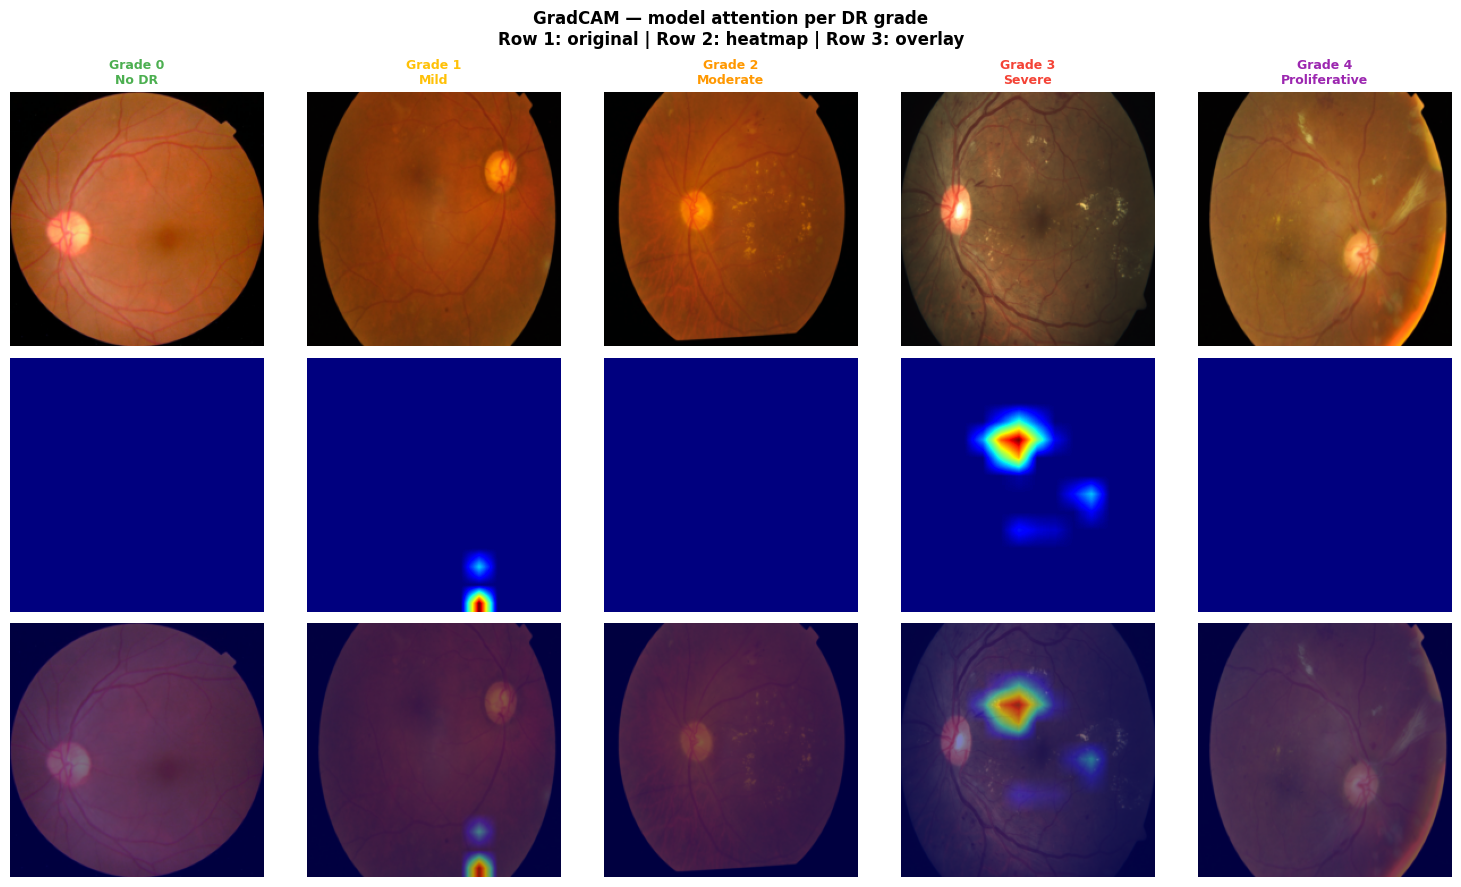

Saved: outputs/04_gradcam.png

Hot regions (red/yellow) = areas the model focused on for its decision.
For higher grades, you should see focus near haemorrhages/lesion areas.


In [10]:
# Show GradCAM for one image per grade
fig, axes = plt.subplots(3, 5, figsize=(15, 9))
fig.suptitle(
    "GradCAM — model attention per DR grade\n"
    "Row 1: original | Row 2: heatmap | Row 3: overlay",
    fontsize=12, fontweight="bold"
)

for grade in range(5):
    # Pick first correct prediction for this grade
    idx = next(
        (i for i in correct_idx if all_labels[i] == grade),
        correct_idx[grade]  # fallback
    )

    img_tensor, true_label = val_dataset[idx]
    inp = img_tensor.unsqueeze(0).to(DEVICE)

    cam, pred_label = gradcam.generate(inp)

    # Resize CAM to 224×224
    cam_resized = np.array(
        Image.fromarray((cam * 255).astype(np.uint8))
             .resize((Config.IMG_SIZE, Config.IMG_SIZE), Image.BILINEAR)
    ) / 255.0

    img_display = np.clip(
        inv_normalize(img_tensor).permute(1, 2, 0).numpy(), 0, 1
    )
    heatmap = cm.jet(cam_resized)[:, :, :3]
    overlay = np.clip(0.5 * img_display + 0.5 * heatmap, 0, 1)

    title = f"Grade {grade}\n{Config.CLASS_NAMES[grade]}"

    axes[0][grade].imshow(img_display)
    axes[0][grade].set_title(title, fontsize=9,
                              color=Config.CLASS_COLORS[grade],
                              fontweight="bold")
    axes[0][grade].axis("off")

    axes[1][grade].imshow(cam_resized, cmap="jet")
    axes[1][grade].axis("off")

    axes[2][grade].imshow(overlay)
    axes[2][grade].axis("off")

plt.tight_layout()
plt.savefig("outputs/04_gradcam.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/04_gradcam.png")
print()
print("Hot regions (red/yellow) = areas the model focused on for its decision.")
print("For higher grades, you should see focus near haemorrhages/lesion areas.")

## 7. Training History Curves (from notebook 03)

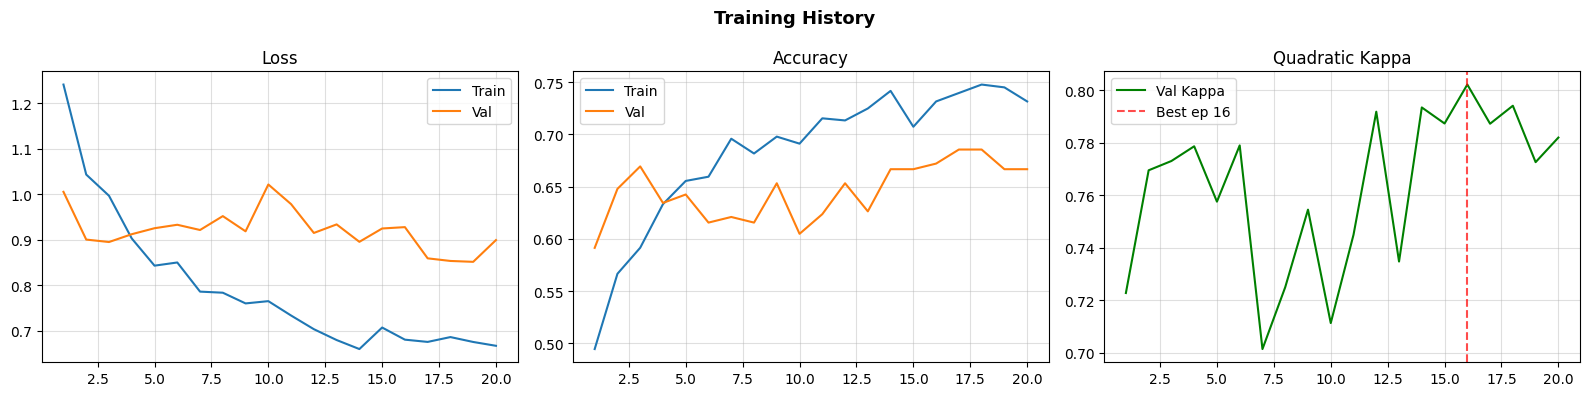

In [11]:
history_df = pd.read_csv("outputs/03_training_history.csv")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Training History", fontsize=13, fontweight="bold")

axes[0].plot(history_df["epoch"], history_df["train_loss"], label="Train")
axes[0].plot(history_df["epoch"], history_df["val_loss"],   label="Val")
axes[0].set_title("Loss"); axes[0].legend(); axes[0].grid(alpha=0.4)

axes[1].plot(history_df["epoch"], history_df["train_acc"], label="Train")
axes[1].plot(history_df["epoch"], history_df["val_acc"],   label="Val")
axes[1].set_title("Accuracy"); axes[1].legend(); axes[1].grid(alpha=0.4)

best_epoch = history_df["val_kappa"].idxmax() + 1
axes[2].plot(history_df["epoch"], history_df["val_kappa"], color="green", label="Val Kappa")
axes[2].axvline(best_epoch, color="red", linestyle="--", alpha=0.7,
                label=f"Best ep {best_epoch}")
axes[2].set_title("Quadratic Kappa"); axes[2].legend(); axes[2].grid(alpha=0.4)

plt.tight_layout()
plt.savefig("outputs/04_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Final Summary

In [13]:
best_kappa_epoch = history_df.loc[history_df["val_kappa"].idxmax()]

print("=" * 55)
print("  EVALUATION SUMMARY")
print("=" * 55)
print(f"  Val Loss           : {val_loss:.4f}")
print(f"  Val Accuracy       : {val_acc*100:.2f}%")
print(f"  Quadratic Kappa    : {val_kappa:.4f}")
print(f"  Best epoch         : {int(best_kappa_epoch['epoch'])}")
print()
print("  Per-class F1:")
for i, (name, score) in enumerate(zip(Config.CLASS_NAMES, f1)):
    bar = "█" * int(score * 20)
    print(f"    Grade {i} ({name:<15}): {score:.4f}  {bar}")
print()
print("  Saved outputs:")
print("    outputs/04_confusion_matrix.png")
print("    outputs/04_per_class_metrics.png")
print("    outputs/04_correct_vs_incorrect.png")
print("    outputs/04_gradcam.png")
print("    outputs/04_training_curves.png")
print("=" * 55)

  EVALUATION SUMMARY
  Val Loss           : 0.9280
  Val Accuracy       : 67.20%
  Quadratic Kappa    : 0.8022
  Best epoch         : 16

  Per-class F1:
    Grade 0 (No DR          ): 0.9469  ██████████████████
    Grade 1 (Mild           ): 0.6562  █████████████
    Grade 2 (Moderate       ): 0.5859  ███████████
    Grade 3 (Severe         ): 0.4419  ████████
    Grade 4 (Proliferative  ): 0.5280  ██████████

  Saved outputs:
    outputs/04_confusion_matrix.png
    outputs/04_per_class_metrics.png
    outputs/04_correct_vs_incorrect.png
    outputs/04_gradcam.png
    outputs/04_training_curves.png
